In [1]:
from resources.imports import *

from resources.MLdata import *
from resources.MLfunc import *
from resources.calculations import get_ductileData, calcUT

import subprocess

import torch 
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.optim import optimize_acqf
from botorch.acquisition import UpperConfidenceBound
from gpytorch.mlls import ExactMarginalLogLikelihood

In [2]:
os.chdir("C:\\temp")

DAT = DATA(path=1, 
           path_add="Target-xs",
           load=True, 
           LAT="FCC", 
           dis="disNodes", 
           mechMode="UT",
           dN=0.2, 
           model="MLP",
           format=1)

LAT = DAT.LAT
nnx = 16
l = 10
mode = DAT.mechTest
material = "ti"
rD = 0.2
dis = DAT.dis
dN = 0.2
distribution = "opt-f" if DAT.path_add == "Frequency" else "opt"
target = "xs" if DAT.path_add == "Target-xs" else "all"
initial = 1
nJobs = 1
CPUs = 12
Fout = 100
Hout = 200
pDir = f"{DAT.PATH}/Opt"

argv = f"{LAT} {nnx} {l} {mode.lower()} {material} {rD} {dis} {dN} {distribution} {target} {initial} {nJobs} {CPUs} {Fout} {Hout} {pDir} OptLoop"

In [3]:
scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(DAT.all_in)

DAT.all_in.shape, DAT.all_out.shape, DAT.allProps.shape

((446, 234), (446, 201), (3, 446))

In [4]:
# check = pd.read_csv(r"C:\temp\transfer\IN-nDuctile-tri-30-20disNodes-uni-xs-1.csv", header=None).drop(columns=0).to_numpy().flatten()
# check1 = check #pd.read_csv(r"Z:\p1\data\Ti\disNodes\Target-xs\0.2\tri\transfer\IN-nDuctile-tri-30-20disNodes-lhs-xs-1.csv", header=None).drop(columns=0).to_numpy().flatten()

# check2 = pd.DataFrame([DAT.perINr_df.to_numpy().flatten(), check, check1])
# d_check = check2 - check2.iloc[0].values
# fixed = d_check.loc[:, (d_check == 0.0).all()].columns
# d_check_ = d_check.drop(columns=fixed)

# # for i,j,k,m in zip(d_check_.columns, d_check_.iloc[0], d_check_.iloc[1], d_check_.iloc[2]):
# #     print(i, j, k, m)
# check.shape, check1.shape, d_check_.shape

# FEA Functions

In [5]:
def FEA_run(x_new, iter):
    new_sample_file = f"{DAT.PATH}/Opt/BO_sample{iter}.txt"
    np.savetxt(new_sample_file, x_new.flatten()[np.newaxis], fmt='%.6f')

    try:
        print("-> Running Abaqus simulation and post-processing...")
        abq_argv = f"{argv} {iter}"
        
        abq_run_file = r"C:\\Users\\exy053\\Documents\\p1git-Lattices\\SIMscripts\\A1_FractureToughness-Ductility.py"
        abq_run_cmd = f"abaqus cae noGUI={abq_run_file} -- {abq_argv}"
        subprocess.run(abq_run_cmd, shell=True, check=True)

        abq_inPP_file = r"C:\\Users\\exy053\\Documents\\p1git-Lattices\\SIMscripts\\A2_INpostProcess.py"
        abq_inPP_cmd = f"abaqus cae noGUI={abq_inPP_file} -- {abq_argv}"
        subprocess.run(abq_inPP_cmd, shell=True, check=True)

        abq_outPP_file = r"C:\\Users\\exy053\\Documents\\p1git-Lattices\\SIMscripts\\A2_OUTpostProcess.py"
        abq_outPP_cmd = f"abaqus cae noGUI={abq_outPP_file} -- {abq_argv}"
        subprocess.run(abq_outPP_cmd, shell=True, check=True)

        CSVout = f"{DAT.PATH}/Opt/transfer/OUT-Ductile-{LAT}-{int(nnx)}-{int(dN*100)}{dis}-opt-{target}-{iter}.csv"
        UTdf = get_ductileData(CSVout, crit=0.25)
        ductility, strength, stiffness = calcUT(UTdf)
        score = ductility
        return score
    
    except subprocess.CalledProcessError as e:
        print(f"!!! An Abaqus process failed: {e}")
        return 0

    except Exception as e:
        print(f"!!! An unexpected error occurred in the FEA workflow: {e}")
        return 0

# Bayesian Optimization

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.double

print(f"Using device: {device}")

class BoTorchOptimizer:
    def __init__(
        self,
        fitness_fn,
        input_shape,
        bounds=(-0.2, 0.2),
        log_file=f"{DAT.PATH}/Opt/BO_log.txt",
        X_initial=None,
        y_initial=None
    ):
        self.fitness_fn = fitness_fn
        self.input_shape = input_shape
        self.dim = np.prod(self.input_shape)
        
        self.bounds = torch.tensor( [[bounds[0]] * self.dim, [bounds[1]] * self.dim], device=device, dtype=dtype)
        
        self.log_file = log_file
        if not os.path.exists(f"{DAT.PATH}/Opt"):
            os.makedirs(f"{DAT.PATH}/Opt")
        if os.path.exists(self.log_file):
            os.remove(self.log_file)
            
        self.train_X = None
        self.train_Y = None
        
        if X_initial is not None and y_initial is not None:
            print(f"Loading {len(y_initial)} initial data points to warm-start the optimizer.")
            self.train_X = torch.tensor(X_initial.reshape(len(y_initial), self.dim), device=device, dtype=dtype)
            self.train_Y = torch.tensor(y_initial, device=device, dtype=dtype).unsqueeze(-1)

    def _get_fitted_model(self):
        model = SingleTaskGP(self.train_X, self.train_Y)
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)
        return model

    def _report_progress(self, iteration, history):
        with open(self.log_file, 'a') as f:
            f.write(f"Iteration: {iteration:4} | Best Fitness Found: {max(history):10.4f}\n")
        
        plt.clf()
        plt.plot(history, marker='o', linestyle='-', markersize=4)
        plt.title(f'BoTorch Convergence (Iter: {iteration})')
        plt.xlabel('Iteration')
        plt.ylabel('Best Fitness Score Found')
        plt.grid(True)
        plt.tight_layout()
        plt.pause(0.01)

    def run(self, n_iterations=50, n_initial_points=10, beta=4.0):
        if self.train_X is None:
            X_init_np = np.random.uniform(self.bounds[0,0].item(), self.bounds[1,0].item(), size=(n_initial_points, self.dim))
            y_init_np = np.array([self.fitness_fn(x.reshape(self.input_shape)) for x in X_init_np])
            self.train_X = torch.tensor(X_init_np, device=device, dtype=dtype)
            self.train_Y = torch.tensor(y_init_np, device=device, dtype=dtype).unsqueeze(-1)
        
        history = [self.train_Y.max().item()]
        
        plt.ion()
        fig = plt.figure(figsize=(10, 6))
        self._report_progress(0, history)

        for i in range(1, n_iterations + 1):
            print(f"\n--- Iteration {i}/{n_iterations} ---")

            print("1. Fitting the Gaussian Process model...")
            model = self._get_fitted_model()
            
            print("2. Defining and optimizing the acquisition function...")
            acq_function = UpperConfidenceBound(model, beta=beta)
            
            candidate, acq_value = optimize_acqf(
                acq_function=acq_function,
                bounds=self.bounds,
                q=1, # Number of candidates to generate (1 for sequential)
                num_restarts=20,
                raw_samples=512, # Number of samples for initialization
            )
            
            new_x = candidate.detach()
            
            print("3. Evaluating new candidate with the expensive fitness function...")
            physical_x = new_x.cpu().numpy().reshape(1,-1)
            physical_x = scaler.inverse_transform(physical_x)
            physical_x = physical_x.reshape(self.input_shape)
            new_y_val = self.fitness_fn(physical_x, i)
            print(f"   -> Score found: {new_y_val:.4f}")
            
            new_y = torch.tensor([[new_y_val]], device=device, dtype=dtype)
            
            self.train_X = torch.cat([self.train_X, new_x])
            self.train_Y = torch.cat([self.train_Y, new_y])
            
            history.append(self.train_Y.max().item())
            self._report_progress(i, history)

        plt.ioff()
        print("\nOptimization finished.")
        plt.show()
        
        best_idx = self.train_Y.argmax()
        best_solution_tensor = self.train_X[best_idx]
        best_score = self.train_Y[best_idx].item()
        
        # Return results as NumPy arrays
        return best_solution_tensor.cpu().numpy().reshape(self.input_shape), best_score

Using device: cpu


Loading 446 initial data points to warm-start the optimizer.


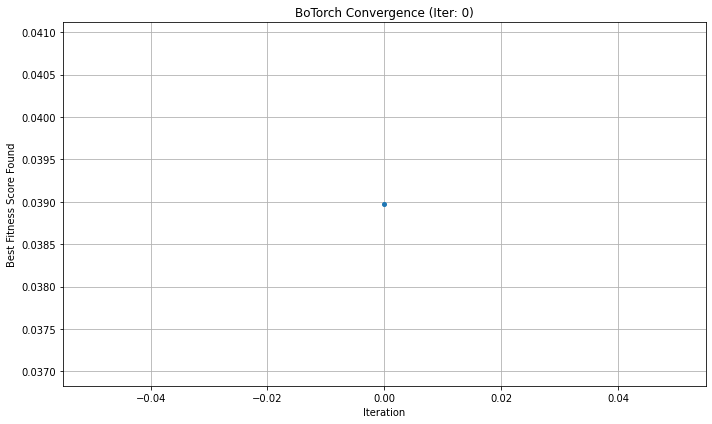


--- Iteration 1/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0234


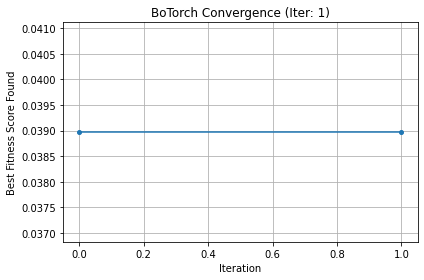


--- Iteration 2/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0265


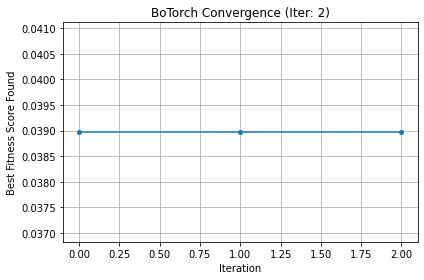


--- Iteration 3/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0278


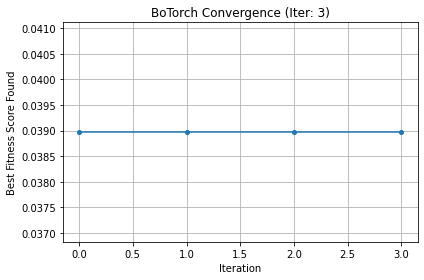


--- Iteration 4/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0225


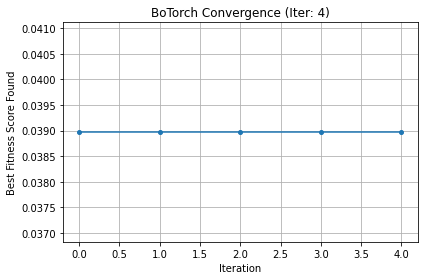


--- Iteration 5/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0232


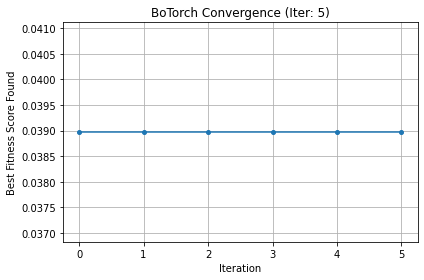


--- Iteration 6/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0279


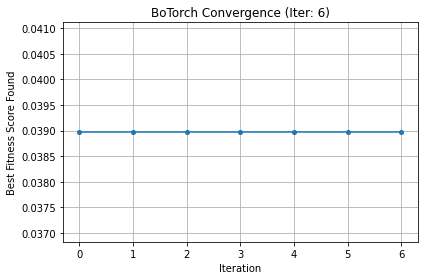


--- Iteration 7/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0238


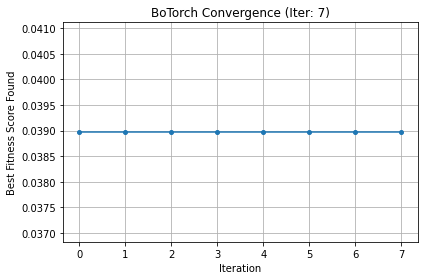


--- Iteration 8/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0238


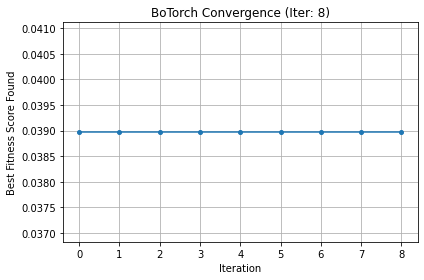


--- Iteration 9/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0315


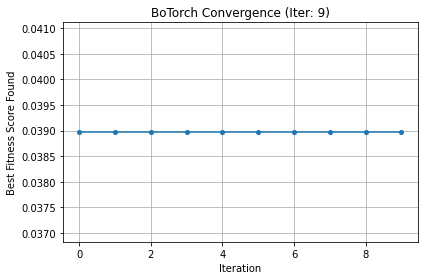


--- Iteration 10/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0240


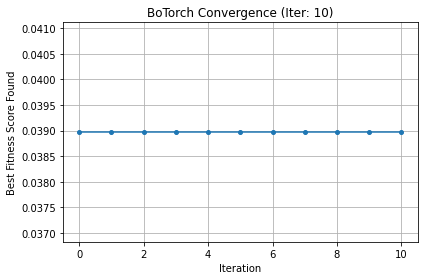


--- Iteration 11/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0227


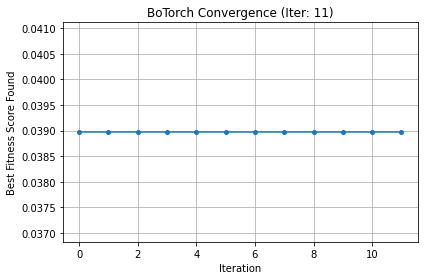


--- Iteration 12/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0233


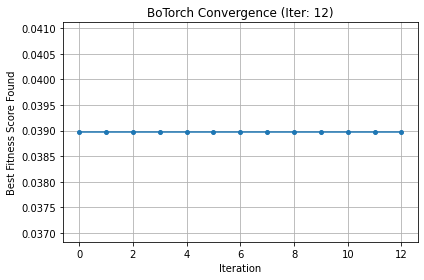


--- Iteration 13/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0259


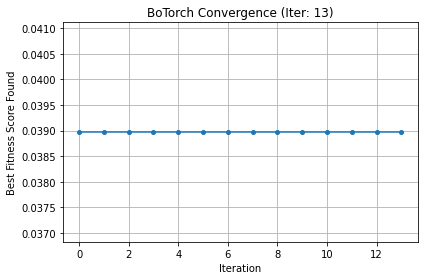


--- Iteration 14/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0230


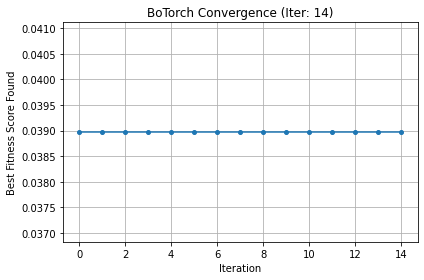


--- Iteration 15/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0255


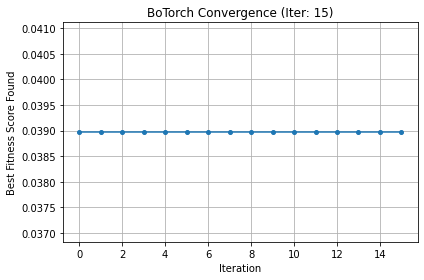


--- Iteration 16/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0216


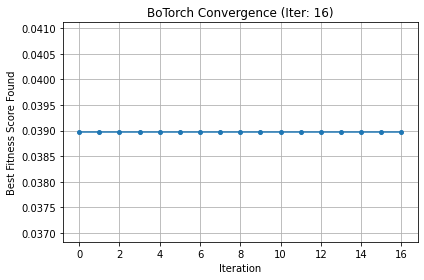


--- Iteration 17/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0212


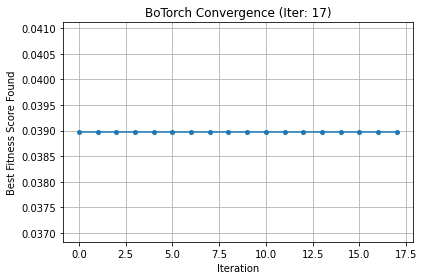


--- Iteration 18/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0246


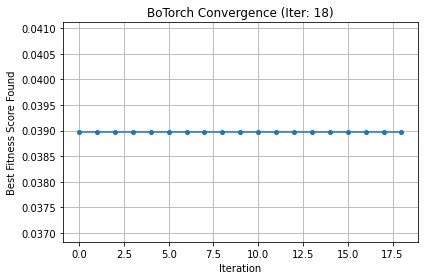


--- Iteration 19/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...
   -> Score found: 0.0253


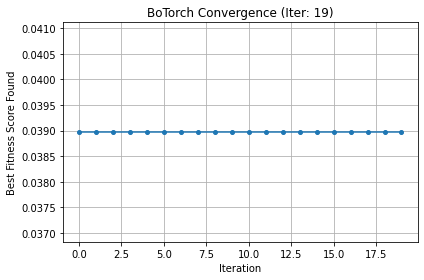


--- Iteration 20/20 ---
1. Fitting the Gaussian Process model...


c:\Programs\Python39\lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.0265], dtype=torch.float64), std = tensor([0.0043], dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


2. Defining and optimizing the acquisition function...
3. Evaluating new candidate with the expensive fitness function...
-> Running Abaqus simulation and post-processing...


KeyboardInterrupt: 

In [7]:
INPUT_SHAPE = DAT.all_in[0].shape
LOWER_BOUND = min(scaler.transform(DAT.all_in).flatten())
UPPER_BOUND = max(scaler.transform(DAT.all_in).flatten())

botorch_optimizer = BoTorchOptimizer(
    fitness_fn=FEA_run,
    input_shape=INPUT_SHAPE,
    bounds=(LOWER_BOUND, UPPER_BOUND),
    X_initial=scaler.transform(DAT.all_in),
    y_initial=DAT.allProps[0]
)

solution, score = botorch_optimizer.run(n_iterations=20, beta=4.0)

print("\n--- Optimization Complete ---")
print(f"Best Score Found: {score:.6f}")
print("Best Solution Coordinates:\n", solution)

In [11]:
# botorch_optimizer.train_Y

# Genetic Algorithm

# Simulated Annealing

In [5]:
class SimulatedAnnealing:
    def __init__(
        self,
        fitness_fn,
        input_shape,
        bounds=(-0.2, 0.2),
        evaluation_mode='surrogate',
        constraint_fn=None,
        log_file='sa_log.txt'
    ):
        self.fitness_fn = fitness_fn
        self.input_shape = input_shape
        self.low_bound, self.high_bound = bounds
        self.evaluation_mode = evaluation_mode
        self.constraint_fn = constraint_fn
        self.log_file = log_file

        if self.evaluation_mode == 'fea':
            self.fitness_cache = {}
            
        if os.path.exists(self.log_file):
            os.remove(self.log_file)

    def _evaluate_solution(self, solution):
        if self.constraint_fn and not self.constraint_fn(solution):
            return -np.inf

        if self.evaluation_mode == 'fea':
            solution_tuple = tuple(solution.flatten())
            if solution_tuple in self.fitness_cache:
                return self.fitness_cache[solution_tuple]
            else:
                score = self.fitness_fn(solution)
                self.fitness_cache[solution_tuple] = score
                return score
        else:
            return self.fitness_fn(solution)

    def _get_neighbor(self, solution, temperature, initial_temp):
        neighbor = solution.copy()
        temp_ratio = temperature / initial_temp
        
        step_size = (self.high_bound - self.low_bound) * 0.2 * temp_ratio + 1e-4

        mutation_mask = np.random.rand(*self.input_shape) < (0.5 * temp_ratio + 0.05)
        noise = np.random.normal(0, step_size, size=self.input_shape)
        
        neighbor[mutation_mask] += noise[mutation_mask]
        np.clip(neighbor, self.low_bound, self.high_bound, out=neighbor)
        return neighbor

    def _report_progress(self, iteration, best_fitness, temp, history):
        with open(self.log_file, 'a') as f:
            f.write(f"Iteration: {iteration:5} | Best Fitness: {best_fitness:10.4f} | Temp: {temp:8.4f}\n")
        
        plt.clf()
        plt.plot(history, marker='.', linestyle='-', markersize=4)
        plt.title(f'Live SA Convergence (Iter: {iteration})')
        plt.xlabel('Iteration')
        plt.ylabel('Best Fitness Score')
        plt.grid(True)
        plt.tight_layout()
        plt.pause(0.01)

    def run(self, n_iterations=2000, initial_temp=1.0, cooling_rate=0.995):
        current_solution = np.random.uniform(self.low_bound, self.high_bound, size=self.input_shape)
        current_energy = self._evaluate_solution(current_solution)
        
        best_solution_so_far = current_solution.copy()
        best_energy_so_far = current_energy
        
        temperature = initial_temp
        history = []
        
        plt.ion()
        fig = plt.figure(figsize=(10, 6))

        for i in range(1, n_iterations + 1):
            neighbor = self._get_neighbor(current_solution, temperature, initial_temp)
            neighbor_energy = self._evaluate_solution(neighbor)
            
            delta_energy = current_energy - neighbor_energy
            
            if delta_energy < 0 or np.random.rand() < np.exp(delta_energy / temperature):
                current_solution = neighbor
                current_energy = neighbor_energy
                
            if current_energy > best_energy_so_far:
                best_energy_so_far = current_energy
                best_solution_so_far = current_solution.copy()
            
            temperature *= cooling_rate
            history.append(best_energy_so_far)
            self._report_progress(i, best_energy_so_far, temperature, history)
            
        plt.ioff()
        print("\nOptimization finished.")
        plt.show()
        return best_solution_so_far, best_energy_so_far

# Particle Swarm Optimization (PSO)

In [ ]:
class ParticleSwarmOptimization:
    def __init__(
        self,
        fitness_fn,
        input_shape,
        swarm_size=50,
        bounds=(-0.2, 0.2),
        evaluation_mode='surrogate',
        constraint_fn=None,
        log_file='pso_log.txt'
    ):
        self.fitness_fn = fitness_fn
        self.input_shape = input_shape
        self.swarm_size = swarm_size
        self.low_bound, self.high_bound = bounds
        self.evaluation_mode = evaluation_mode
        self.constraint_fn = constraint_fn
        self.log_file = log_file

        self.positions = np.random.uniform(self.low_bound, self.high_bound, (self.swarm_size,) + self.input_shape)
        self.velocities = np.zeros_like(self.positions)
        
        self.pbest_positions = self.positions.copy()
        self.pbest_scores = np.full(self.swarm_size, -np.inf)
        
        self.gbest_position = None
        self.gbest_score = -np.inf

        if self.evaluation_mode == 'fea':
            self.fitness_cache = {}
            
        if os.path.exists(self.log_file):
            os.remove(self.log_file)

    def _evaluate_particle(self, particle_position):
        if self.constraint_fn and not self.constraint_fn(particle_position):
            return -np.inf

        if self.evaluation_mode == 'fea':
            particle_tuple = tuple(particle_position.flatten())
            if particle_tuple in self.fitness_cache:
                return self.fitness_cache[particle_tuple]
            else:
                score = self.fitness_fn(particle_position)
                self.fitness_cache[particle_tuple] = score
                return score
        else:
            return self.fitness_fn(particle_position)
            
    def _update_bests(self):
        for i in range(self.swarm_size):
            score = self._evaluate_particle(self.positions[i])
            if score > self.pbest_scores[i]:
                self.pbest_scores[i] = score
                self.pbest_positions[i] = self.positions[i].copy()
                
        best_particle_idx = np.argmax(self.pbest_scores)
        if self.pbest_scores[best_particle_idx] > self.gbest_score:
            self.gbest_score = self.pbest_scores[best_particle_idx]
            self.gbest_position = self.pbest_positions[best_particle_idx].copy()
            
    def _report_progress(self, iteration, history):
        with open(self.log_file, 'a') as f:
            f.write(f"Iteration: {iteration:4} | Global Best Fitness: {self.gbest_score:10.4f}\n")
        
        plt.clf()
        plt.plot(history, marker='o', linestyle='-', markersize=4)
        plt.title(f'Live PSO Convergence (Iter: {iteration})')
        plt.xlabel('Iteration')
        plt.ylabel('Global Best Fitness Score')
        plt.grid(True)
        plt.tight_layout()
        plt.pause(0.01)

    def run(self, n_iterations=100, w_max=0.9, w_min=0.4, c1=2.0, c2=2.0):
        self._update_bests()
        history = [self.gbest_score]

        plt.ion()
        fig = plt.figure(figsize=(10, 6))

        for i in range(1, n_iterations + 1):
            w = w_max - (w_max - w_min) * (i / n_iterations)

            r1 = np.random.rand(self.swarm_size, 1, 1)
            r2 = np.random.rand(self.swarm_size, 1, 1)

            cognitive_velocity = c1 * r1 * (self.pbest_positions - self.positions)
            social_velocity = c2 * r2 * (self.gbest_position - self.positions)
            
            self.velocities = w * self.velocities + cognitive_velocity + social_velocity
            
            v_max = (self.high_bound - self.low_bound) * 0.5
            np.clip(self.velocities, -v_max, v_max, out=self.velocities)
            
            self.positions += self.velocities
            np.clip(self.positions, self.low_bound, self.high_bound, out=self.positions)
            
            self._update_bests()
            history.append(self.gbest_score)
            self._report_progress(i, history)
            
        plt.ioff()
        print("\nOptimization finished.")
        plt.show()
        return self.gbest_position, self.gbest_score